Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(240, 232)


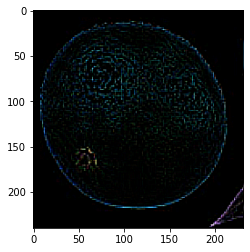

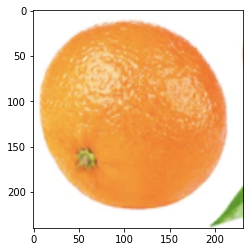

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


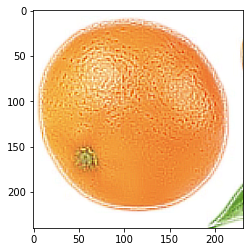

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt 
import math

img = cv2.imread('data/fresh\Screen Shot 2018-06-12 at 11.50.28 PM.png')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
height, width = img_rgb.shape[:2]

print(img_rgb.shape[:2])



edges = cv2.Laplacian(img_rgb, cv2.CV_16S, ksize=3)
# sobel_horizontal = cv2.Sobel(img_rgb, cv2.CV_64F, 1, 0, ksize=0)
# sobel_vertical = cv2.Sobel(img_rgb, cv2.CV_64F, 0, 1, ksize=0)

# edges = cv2.convertScaleAbs(edges)
plt.imshow(edges)
plt.show()

# edges = sobel_vertical + sobel_horizontal
# r,g,b = cv2.split(img_rgb)
# plt.imshow(edges)
# plt.show()
plt.imshow(img_rgb)
plt.show()

# edges_gray = cv2.cvtColor(edges, cv2.COLOR_RGB2GRAY)

r,g,b = cv2.split(img_rgb)
rr,gg,bb= cv2.split(edges)

nr = r + rr
ng = g + gg
nb = b+ bb

image = cv2.merge((nr,ng,nb))
#sharpening
# sharped = edges_gray + img
plt.imshow(image)
plt.show()


In [229]:
# r,g,b = cv2.split(img_rgb)
# r_f = r.flatten()
# g_f = g.flatten()
# b_f = b.flatten()

# er, eg, eb = cv2.split(image)

# er_f = er.flatten()
# eg_f = eg.flatten()
# eb_f = eb.flatten()


# for i in range(len(er_f)):
#     if (er_f[i] == 255  and eg_f[i] == 255 and eb_f[i] == 255):
#         r_f[i] = 0
#         g_f[i] = 0
#         b_f[i] = 0


# for i in range(len(er_f)):
#     if (er_f[i] == maxx):
#         r_f[i] = 256
#     elif eg_f[i] == maxx:
#         g_f[i] = 256
#     elif eb_f[i] == maxx:
#         b_f[i] = 256
#     else:
#         continue


# new_r = np.reshape(r_f, (height, width))
# new_g = np.reshape(g_f, (height, width))
# new_b = np.reshape(b_f, (height, width))


# image = cv2.merge((new_r,new_g,new_b))

# plt.imshow(image)
# plt.show()


# shar = removed + edges
# plt.imshow(shar)
# plt.show()

(55680, 3)


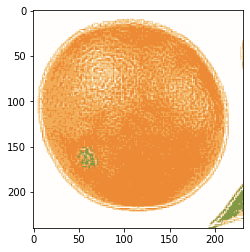

In [230]:
#segmentation

pixel_values = image.reshape((-1, 3))
# convert to float
pixel_values = np.float32(pixel_values)

print(pixel_values.shape)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# number of clusters (K)
k = 5
_, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)


# convert back to 8 bit values
centers = np.uint8(centers)

# flatten the labels array
labels = labels.flatten()
# convert all pixels to the color of the centroids
segmented_image = centers[labels.flatten()]

# reshape back to the original image dimension
segmented_image = segmented_image.reshape(image.shape)
# show the image
plt.imshow(segmented_image)
plt.show()


# print(segmented_image)

In [231]:
maxx = segmented_image.max()
print(maxx)

255


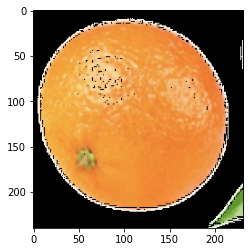

In [232]:
r,g,b = cv2.split(img_rgb)
r_f = r.flatten()
g_f = g.flatten()
b_f = b.flatten()

er, eg, eb = cv2.split(segmented_image)

er_f = er.flatten()
eg_f = eg.flatten()
eb_f = eb.flatten()


# for i in range(len(er_f)):
#     if (er_f[i] == maxx):
#         r_f[i] = 256
#     elif eg_f[i] == maxx:
#         g_f[i] = 256
#     elif eb_f[i] == maxx:
#         b_f[i] = 256
#     else:
#         continue

for i in range(len(er_f)):
    if (er_f[i] == maxx  or eg_f[i] == maxx or eb_f[i] == maxx):
        r_f[i] = 0
        g_f[i] = 0
        b_f[i] = 0


new_r = np.reshape(r_f, (height, width))
new_g = np.reshape(g_f, (height, width))
new_b = np.reshape(b_f, (height, width))


removed = cv2.merge((new_r,new_g,new_b))

plt.imshow(removed)
plt.show()
